In [2]:
!pip install bibtexparser pandas openpyxl matplotlib wordcloud

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for bibtexparser: filename=bibtexparser-1.4.4-py3-none-any.whl size=43609 sha256=9257694e3743db3df4dfc8eb66addd4041f441922d6a5f761b85d7a45ab406e3
  Stored in directory: /root/.cache/pip/wheels/54/f8/e6/ecfceb6af875ddc5096bb3811795ac336f50371009a601454d
Successfully built bibtexparser


In [3]:
import bibtexparser

with open("Eixo3-Lucas-CAPES-BibTex-Combinado.bib", encoding="utf-8") as bibtex_file:
    bib_database = bibtexparser.load(bibtex_file)

print("Total de registros:", len(bib_database.entries))

Total de registros: 64


In [4]:
campos = set()

for artigo in bib_database.entries:
    campos.update(artigo.keys())

for campo in sorted(campos):

    preenchidos = sum(
        1 for artigo in bib_database.entries
        if artigo.get(campo)
    )

    print(f"{campo}: {preenchidos}")

ENTRYTYPE: 64
ID: 64
author: 64
doi: 62
journal: 64
keywords: 0
number: 56
pages: 64
title: 64
volume: 59
year: 64


In [5]:
import pandas as pd

dados = []

for artigo in bib_database.entries:
    dados.append({
        "Titulo": artigo.get("title", ""),
        "Autores": artigo.get("author", ""),
        "Ano": artigo.get("year", ""),
        "Periodico": artigo.get("journal", ""),
        "DOI": artigo.get("doi", "")
    })

df = pd.DataFrame(dados)

print(df.shape)

df.head()

(64, 5)


,Titulo,Autores,Ano,Periodico,DOI
0,A integralidade sufocada em consultas de 20 mi...,"Roberto Magalhães Silva, Andréia Patrícia Gome...",2024,Revista Brasileira de Medicina de Família e Co...,10.5712/rbmfc19(46)4242
1,Revisão sistemática da literatura acerca da pr...,"Ádilo Lages Vieira Passos, Cássio Adriano Braz...",2024,Revista Portuguesa de Investigação Comportamen...,10.31211/rpics.2024.10.1.323
2,Tecnologias de informação e comunicação: revis...,"Alexandra Vasconcelos Antunes Setta, Sérgio Ro...",2024,Revista Brasileira de Saúde Ocupacional,10.1590/2317-6369/02722pt2024v49e6
3,As muitas horas de um contrato zero hora,Lucas Antonio dos Anjos Nascimento,2024,Temáticas,10.20396/tematicas.v32i63.18498
4,Precarização do trabalho em plataformas digita...,"Nara Letícia Pedroso Ramos Rodrigues, Sérgio R...",2024,Saúde em Debate,10.1590/2358-289820241439270p


In [6]:
df["Ano"].value_counts().sort_index()

,count
Ano,
2015,3
2016,2
2017,4
2018,3
2019,6
2020,10
2021,7
2022,12
2023,7


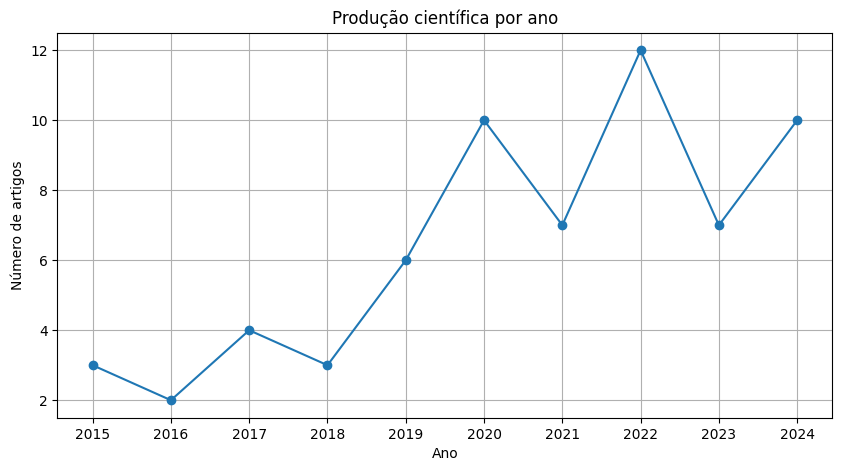

In [7]:
import matplotlib.pyplot as plt

producao = df["Ano"].value_counts().sort_index()

plt.figure(figsize=(10,5))

plt.plot(
    producao.index,
    producao.values,
    marker="o"
)

plt.title("Produção científica por ano")
plt.xlabel("Ano")
plt.ylabel("Número de artigos")

plt.grid(True)

plt.show()

In [8]:
from collections import Counter

texto = " ".join(df["Titulo"].astype(str))

texto = texto.lower()

texto = texto.replace(",", " ")
texto = texto.replace(".", " ")
texto = texto.replace(":", " ")
texto = texto.replace(";", " ")
texto = texto.replace("-", " ")

stopwords = {
    "de","da","do","das","dos",
    "a","o","as","os",
    "e","em","na","no","nas","nos",
    "para","por","com","um","uma",
    "sobre","entre","como","ao","aos",
    "à","às"
}

palavras = [
    p for p in texto.split()
    if len(p) > 3 and p not in stopwords
]

frequencia = Counter(palavras)

top20 = pd.DataFrame(
    frequencia.most_common(20),
    columns=["Palavra","Frequencia"]
)

top20

,Palavra,Frequencia
0,trabalho,32
1,precarização,12
2,uberização,5
3,ensino,5
4,brasil,5
5,formação,4
6,economia,4
7,trabalhadores,4
8,saúde,4
9,professores,4


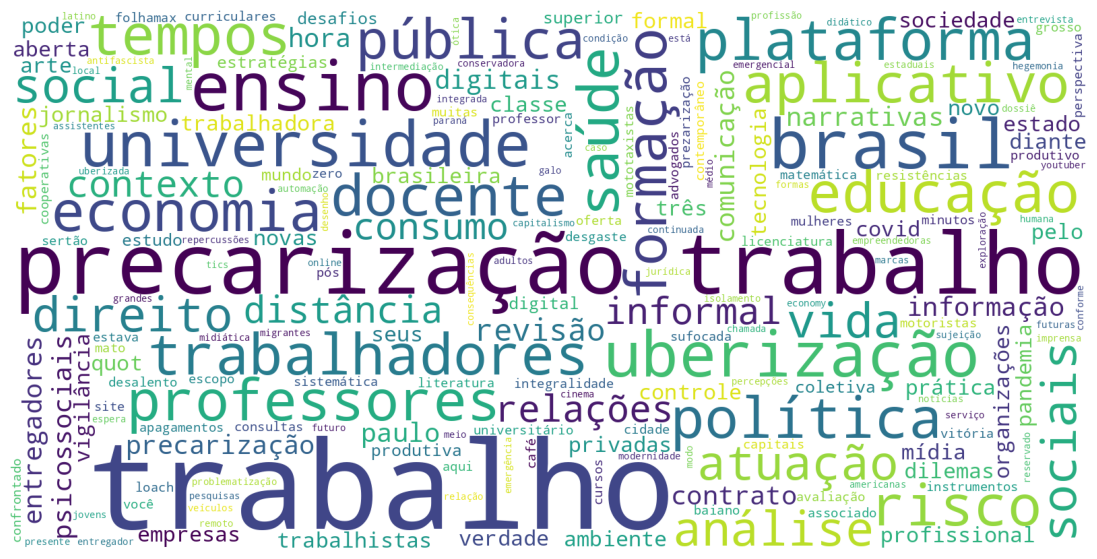

In [9]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wc = WordCloud(
    width=1600,
    height=800,
    background_color="white"
)

wc.generate(" ".join(palavras))

plt.figure(figsize=(14,7))
plt.imshow(wc)
plt.axis("off")
plt.show()

In [10]:
from collections import Counter

lista_autores = []

for autores in df["Autores"]:

    nomes = autores.split(" and ")

    for nome in nomes:
        lista_autores.append(nome.strip())

freq_autores = Counter(lista_autores)

top_autores = pd.DataFrame(
    freq_autores.most_common(20),
    columns=["Autor","Publicacoes"]
)

top_autores

,Autor,Publicacoes
0,"David Silva Franco, Deise Luiza da Silva Ferraz",2
1,"Roberto Magalhães Silva, Andréia Patrícia Gome...",1
2,"Ádilo Lages Vieira Passos, Cássio Adriano Braz...",1
3,"Alexandra Vasconcelos Antunes Setta, Sérgio Ro...",1
4,Lucas Antonio dos Anjos Nascimento,1
5,"Nara Letícia Pedroso Ramos Rodrigues, Sérgio R...",1
6,"Bruno Barreto Bucciarelli, Christiane Barbara ...",1
7,"Sandra Célia Coelho Gomes da Silva, Leane de M...",1
8,"Cristiane Klöpsch, Vinício de Macedo Santos",1
9,"Thiago Cury Luiz, Nayara Fernanda Takahara da ...",1


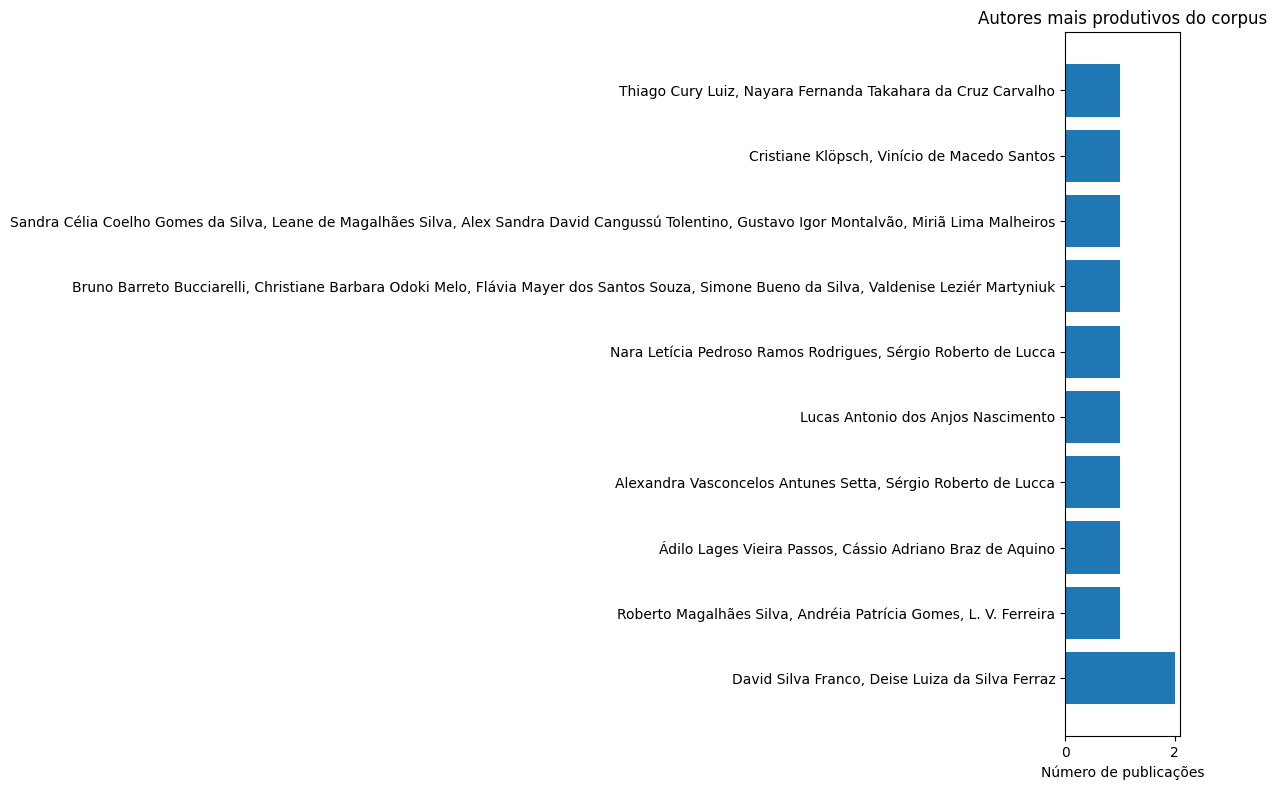

In [11]:
plt.figure(figsize=(12,8))

plt.barh(
    top_autores.head(10)["Autor"],
    top_autores.head(10)["Publicacoes"]
)

plt.title("Autores mais produtivos do corpus")
plt.xlabel("Número de publicações")

plt.tight_layout()

plt.show()

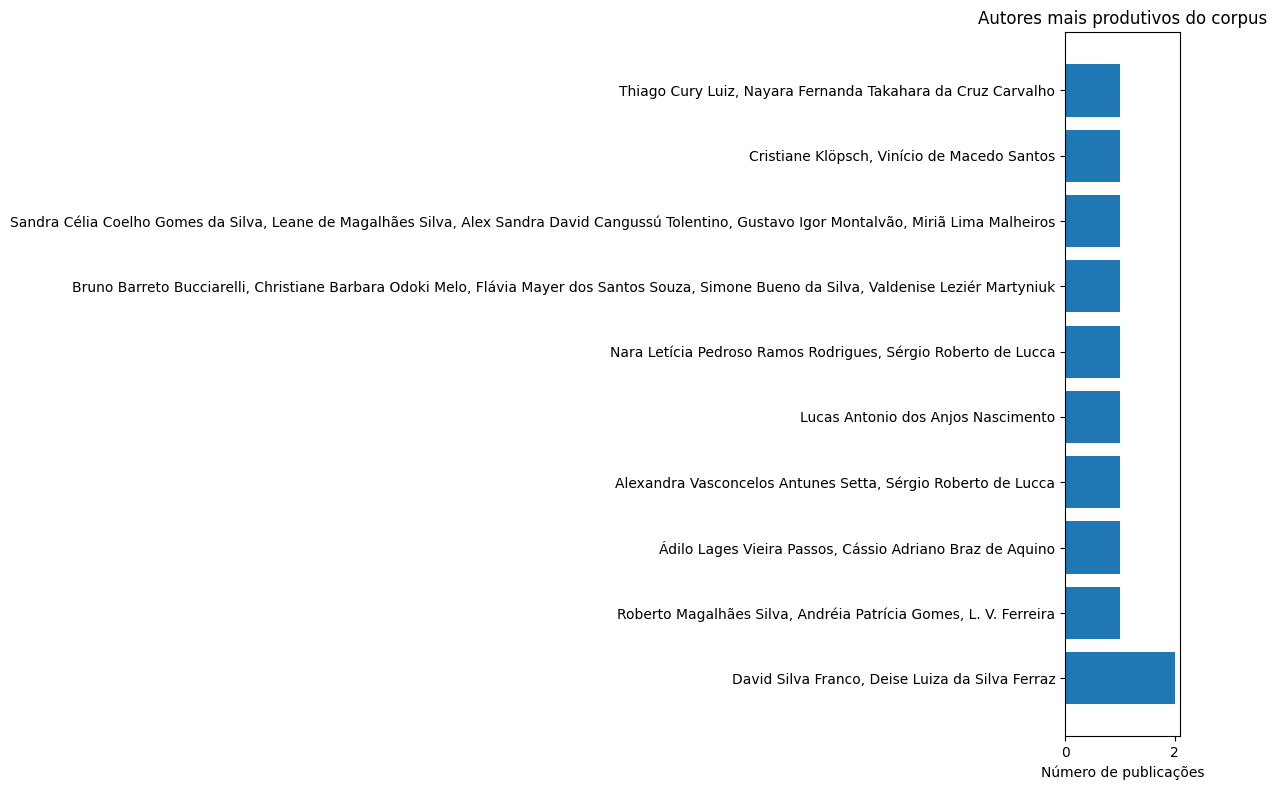

In [12]:
top10 = (
    top_autores.head(10)
    .sort_values(
        by="Publicacoes",
        ascending=False
    )
)

plt.figure(figsize=(12,8))

plt.barh(
    top10["Autor"],
    top10["Publicacoes"]
)

plt.title("Autores mais produtivos do corpus")
plt.xlabel("Número de publicações")

plt.tight_layout()

plt.show()

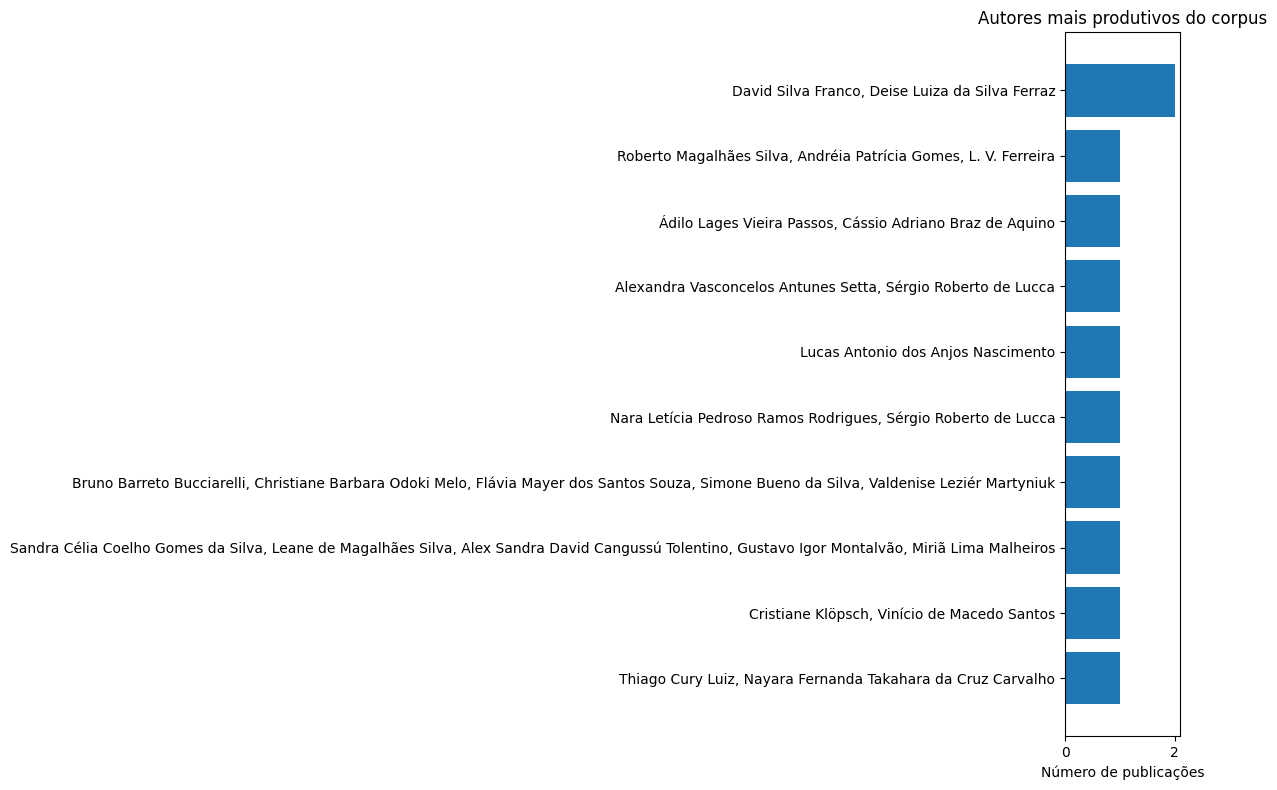

In [13]:
top10 = (
    top_autores.head(10)
    .sort_values(
        by="Publicacoes",
        ascending=False
    )
)

plt.figure(figsize=(12,8))

plt.barh(
    top10["Autor"],
    top10["Publicacoes"]
)

plt.gca().invert_yaxis()

plt.title("Autores mais produtivos do corpus")
plt.xlabel("Número de publicações")

plt.tight_layout()

plt.show()

In [14]:
df["Autores"].head(10)

,Autores
0,"Roberto Magalhães Silva, Andréia Patrícia Gome..."
1,"Ádilo Lages Vieira Passos, Cássio Adriano Braz..."
2,"Alexandra Vasconcelos Antunes Setta, Sérgio Ro..."
3,Lucas Antonio dos Anjos Nascimento
4,"Nara Letícia Pedroso Ramos Rodrigues, Sérgio R..."
5,"Bruno Barreto Bucciarelli, Christiane Barbara ..."
6,"Sandra Célia Coelho Gomes da Silva, Leane de M..."
7,"Cristiane Klöpsch, Vinício de Macedo Santos"
8,"Thiago Cury Luiz, Nayara Fernanda Takahara da ..."
9,"Arnaldo Rizzardo Filho, Alexandre Borba da Sil..."


In [15]:
from collections import Counter

lista_autores = []

for autores in df["Autores"]:

    autores = str(autores)

    nomes = autores.split(",")

    for nome in nomes:

        nome = nome.strip()

        if len(nome) > 3:
            lista_autores.append(nome)

freq_autores = Counter(lista_autores)

top_autores = pd.DataFrame(
    freq_autores.most_common(20),
    columns=["Autor","Publicacoes"]
)

top_autores

,Autor,Publicacoes
0,Sérgio Roberto de Lucca,3
1,David Silva Franco,3
2,Deise Luiza da Silva Ferraz,3
3,Nara Letícia Pedroso Ramos Rodrigues,2
4,Uilmer Rodrigues Xavier da Cruz,2
5,Roberto Magalhães Silva,1
6,Andréia Patrícia Gomes,1
7,L. V. Ferreira,1
8,Ádilo Lages Vieira Passos,1
9,Cássio Adriano Braz de Aquino,1


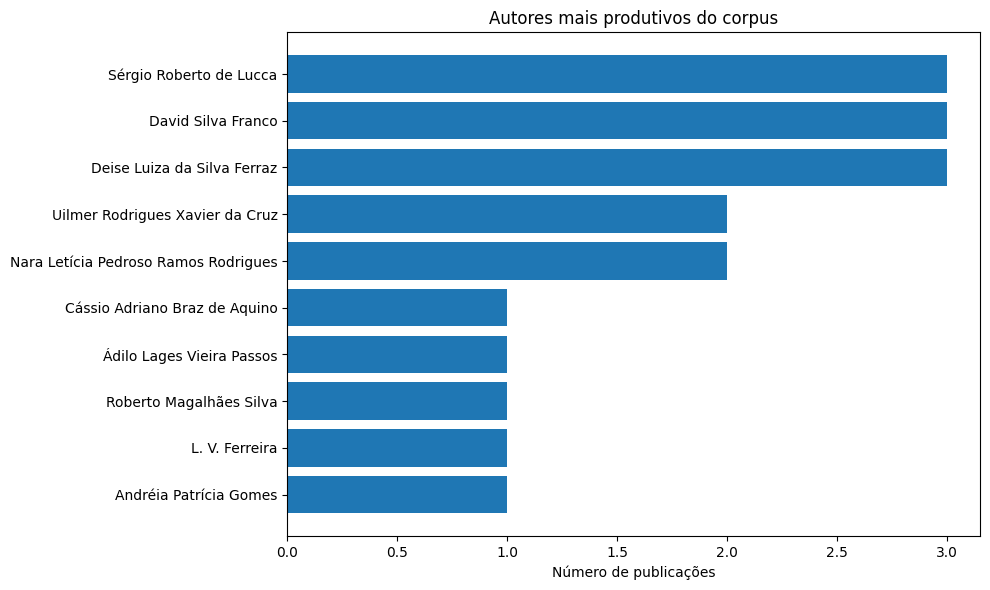

In [16]:
top10 = (
    top_autores.head(10)
    .sort_values(
        by="Publicacoes",
        ascending=True
    )
)

plt.figure(figsize=(10,6))

plt.barh(
    top10["Autor"],
    top10["Publicacoes"]
)

plt.title("Autores mais produtivos do corpus")
plt.xlabel("Número de publicações")

plt.tight_layout()

plt.show()

In [17]:
top_periodicos = (
    df["Periodico"]
    .value_counts()
    .reset_index()
)

top_periodicos.columns = [
    "Periodico",
    "Publicacoes"
]

top_periodicos.head(15)

,Periodico,Publicacoes
0,Revista Katálysis,4
1,Revista Trabalho Necessário,3
2,Reciis,3
3,Ação Midiática – Estudos em Comunicação Socied...,2
4,Lumina,2
5,Eventos Pedagógicos,2
6,Cadernos EBAPE BR,2
7,Distúrbios da Comunicação,2
8,Cadernos de Saúde Pública,2
9,Trabalho (En)Cena,2


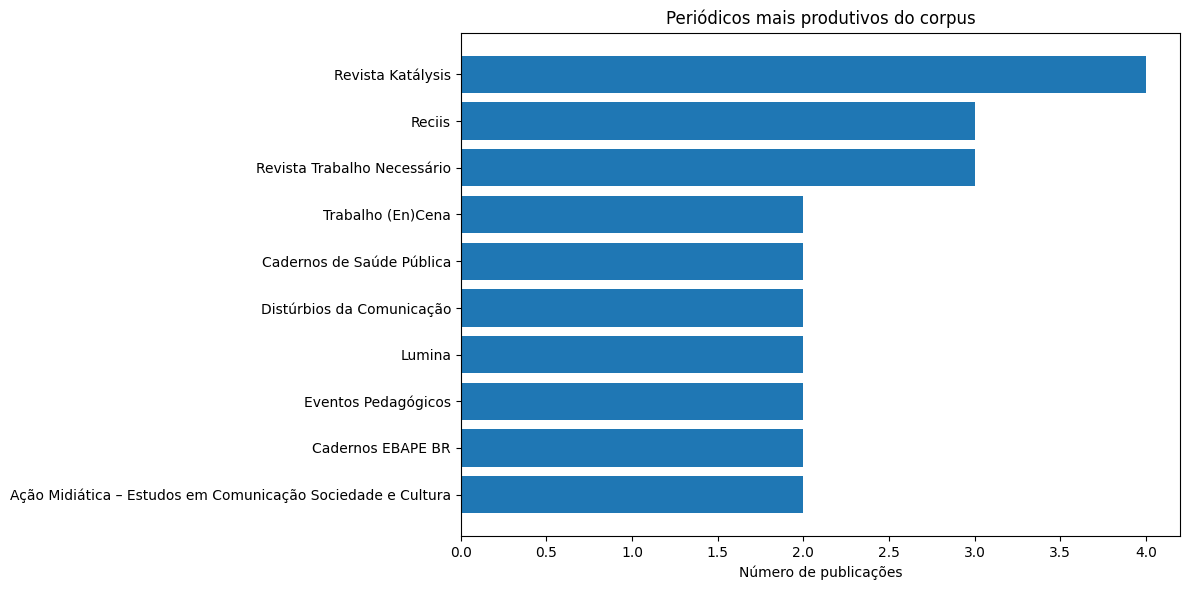

In [18]:
top10_periodicos = (
    top_periodicos.head(10)
    .sort_values(
        by="Publicacoes",
        ascending=True
    )
)

plt.figure(figsize=(12,6))

plt.barh(
    top10_periodicos["Periodico"],
    top10_periodicos["Publicacoes"]
)

plt.title("Periódicos mais produtivos do corpus")
plt.xlabel("Número de publicações")

plt.tight_layout()

plt.show()

In [19]:
len(lista_autores)

155

In [20]:
len(set(lista_autores))

147

In [21]:
len(lista_autores) / len(df)

2.421875

In [22]:
df.to_excel(
    "corpus_trabalhadores_precarizados_completo.xlsx",
    index=False
)

In [24]:
top_autores.to_excel(
    "autores_trabalhadores_precarizados.xlsx",
    index=False
)

In [25]:
top_periodicos.to_excel(
    "periodicos_trabalhadores_precarizados.xlsx",
    index=False
)

In [26]:
producao_ano = (
    df["Ano"]
    .value_counts()
    .sort_index()
    .reset_index()
)

producao_ano.columns = [
    "Ano",
    "Publicacoes"
]

producao_ano.to_excel(
    "producao_por_ano_trabalhadores.xlsx",
    index=False
)

In [27]:
df.to_excel("corpus_trabalhadores_precarizados_completo.xlsx", index=False)
top_autores.to_excel("autores_trabalhadores.xlsx", index=False)
top_periodicos.to_excel("periodicos_trabalhadores.xlsx", index=False)
producao_ano.to_excel("producao_por_ano_trabalhadores.xlsx", index=False)

In [29]:
from collections import Counter

texto = " ".join(df["Titulo"].astype(str))

texto = texto.lower()

texto = texto.replace(",", " ")
texto = texto.replace(".", " ")
texto = texto.replace(":", " ")
texto = texto.replace(";", " ")
texto = texto.replace("-", " ")

stopwords = {
    "de","da","do","das","dos",
    "a","o","as","os",
    "e","em","na","no","nas","nos",
    "para","por","com","um","uma",
    "sobre","entre","como","ao","aos",
    "à","às"
}

palavras = [
    p for p in texto.split()
    if len(p) > 3 and p not in stopwords
]

frequencia = Counter(palavras)

top15 = pd.DataFrame(
    frequencia.most_common(15),
    columns=["Palavra","Frequencia"]
)

top15

,Palavra,Frequencia
0,trabalho,32
1,precarização,12
2,uberização,5
3,ensino,5
4,brasil,5
5,formação,4
6,economia,4
7,trabalhadores,4
8,saúde,4
9,professores,4


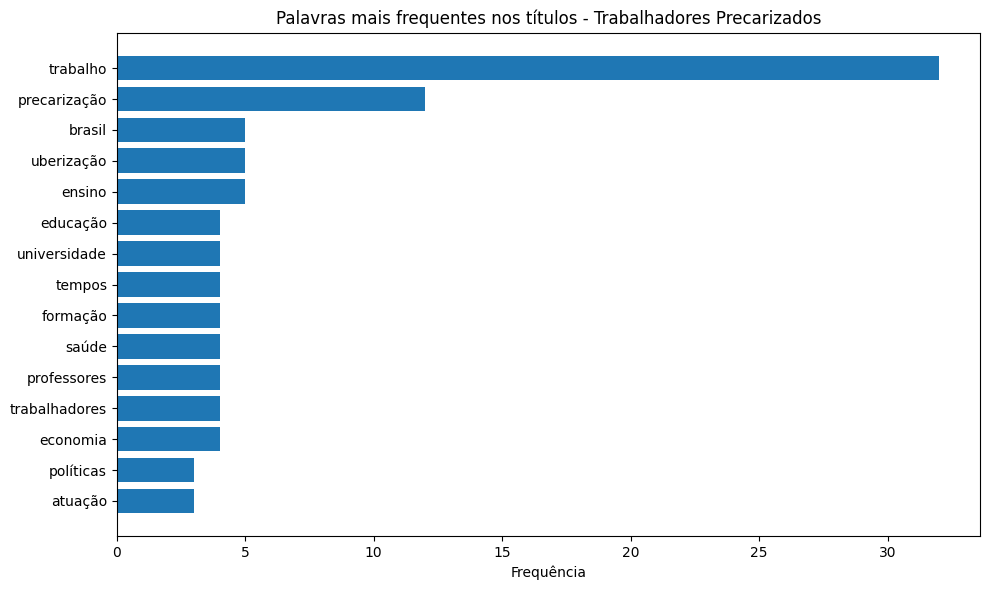

In [30]:
import matplotlib.pyplot as plt

top15 = (
    top15
    .sort_values(
        by="Frequencia",
        ascending=True
    )
)

plt.figure(figsize=(10,6))

plt.barh(
    top15["Palavra"],
    top15["Frequencia"]
)

plt.title("Palavras mais frequentes nos títulos - Trabalhadores Precarizados")
plt.xlabel("Frequência")
plt.ylabel("")

plt.tight_layout()

plt.show()

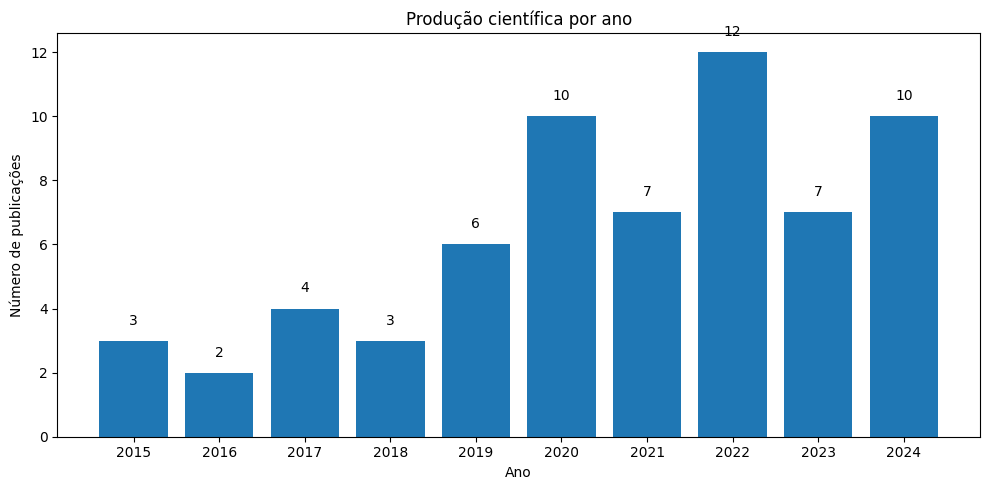

In [31]:
import matplotlib.pyplot as plt

producao_ano = (
    df["Ano"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10,5))

barras = plt.bar(
    producao_ano.index.astype(str),
    producao_ano.values
)

for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width()/2,
        altura + 0.5,
        str(int(altura)),
        ha='center'
    )

plt.title("Produção científica por ano")
plt.xlabel("Ano")
plt.ylabel("Número de publicações")

plt.ylim(bottom=0)

plt.tight_layout()
plt.show()